# ZINC Oracle Study

This notebook isolates the effect of the feasibility oracle on an already-trained ZINC generator.

It assumes:

- a trained generator snapshot has been uploaded or copied locally,
- a cached ZINC graph corpus already exists under `notebooks/datasets/zinc`,
- you want side-by-side oracle-off versus oracle-on comparisons under the same notebook workflow.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

for _root in [Path.cwd(), *Path.cwd().parents]:
    if (_root / '_notebook_bootstrap.py').exists():
        _root_str = str(_root.resolve())
        if _root_str not in sys.path:
            sys.path.insert(0, _root_str)
        break
else:
    raise ModuleNotFoundError("Could not locate '_notebook_bootstrap.py' from current notebook directory.")

from _notebook_bootstrap import configure_notebook

globals().update(configure_notebook(require_nsppk=True, print_torch=True))

del _root, _root_str

from conditional_node_field_graph_generator.extensions.molecular import (
    draw_molecules,
    load_zinc_graph_dataset,
)
from conditional_node_field_graph_generator.persistence import load_graph_generator


PyTorch version: 2.2.2
CUDA available: False


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


Enabling RDKit 2025.09.3 jupyter extensions


## Helpers

The helpers below keep the oracle comparison logic explicit and reproducible.


In [2]:
def show_molecules(graphs, n=12, title=None, legends=None):
    graphs = list(graphs)[:n]
    if title:
        print(title)
    if not graphs:
        print('No graphs to display.')
        return
    draw_molecules(graphs, legends=legends)


def _set_all_seeds(seed):
    random.seed(int(seed))
    np.random.seed(int(seed))


def compare_oracle_samples(
    graph_generator,
    seed_graphs,
    *,
    n_samples=8,
    apply_feasibility_filtering=True,
    seed=7,
):
    seed_graphs = list(seed_graphs)
    show_molecules(seed_graphs, n=len(seed_graphs), title='Conditioning molecules')

    _set_all_seeds(seed)
    without_oracle = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_samples,
        apply_feasibility_filtering=apply_feasibility_filtering,
        use_feasibility_oracle=False,
    )

    _set_all_seeds(seed)
    with_oracle = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_samples,
        apply_feasibility_filtering=apply_feasibility_filtering,
        use_feasibility_oracle=True,
    )

    summary = pd.DataFrame(
        [
            {
                'setting': 'oracle_off',
                'returned_graphs': len(without_oracle),
                'mean_nodes': np.mean([g.number_of_nodes() for g in without_oracle]) if without_oracle else np.nan,
                'mean_edges': np.mean([g.number_of_edges() for g in without_oracle]) if without_oracle else np.nan,
            },
            {
                'setting': 'oracle_on',
                'returned_graphs': len(with_oracle),
                'mean_nodes': np.mean([g.number_of_nodes() for g in with_oracle]) if with_oracle else np.nan,
                'mean_edges': np.mean([g.number_of_edges() for g in with_oracle]) if with_oracle else np.nan,
            },
        ]
    )
    display(summary)
    show_molecules(without_oracle, n=n_samples, title='Oracle OFF samples')
    show_molecules(with_oracle, n=n_samples, title='Oracle ON samples')
    return {'summary': summary, 'oracle_off': without_oracle, 'oracle_on': with_oracle}


def compare_oracle_score(
    graph_generator,
    *,
    n_samples=24,
    max_feasibility_attempts=4,
    feasibility_candidates_per_attempt=8,
    seed=11,
):
    original_value = graph_generator.use_feasibility_oracle
    try:
        _set_all_seeds(seed)
        graph_generator.use_feasibility_oracle = False
        score_without = graph_generator.score_feasible_rate(
            n_samples=n_samples,
            max_feasibility_attempts=max_feasibility_attempts,
            feasibility_candidates_per_attempt=feasibility_candidates_per_attempt,
            verbose=False,
        )

        _set_all_seeds(seed)
        graph_generator.use_feasibility_oracle = True
        score_with = graph_generator.score_feasible_rate(
            n_samples=n_samples,
            max_feasibility_attempts=max_feasibility_attempts,
            feasibility_candidates_per_attempt=feasibility_candidates_per_attempt,
            verbose=False,
        )
    finally:
        graph_generator.use_feasibility_oracle = original_value

    score_frame = pd.DataFrame([score_without, score_with], index=['oracle_off', 'oracle_on'])
    display(score_frame)
    return score_frame


def compare_oracle_interpolation(
    graph_generator,
    graph_a,
    graph_b,
    *,
    k=5,
    apply_feasibility_filtering=True,
):
    oracle_off = graph_generator.interpolate(
        graph_a,
        graph_b,
        k=k,
        apply_feasibility_filtering=apply_feasibility_filtering,
        apply_feasibility_oracle=False,
    )
    oracle_on = graph_generator.interpolate(
        graph_a,
        graph_b,
        k=k,
        apply_feasibility_filtering=apply_feasibility_filtering,
        apply_feasibility_oracle=True,
    )

    summary = pd.DataFrame(
        {
            'step': oracle_on['summary']['step'],
            't': oracle_on['summary']['t'],
            'oracle_off_decoded': oracle_off['summary']['decoded'],
            'oracle_on_decoded': oracle_on['summary']['decoded'],
        }
    )
    display(summary)
    show_molecules([graph_a, graph_b], n=2, title='Interpolation endpoints')
    show_molecules(oracle_off['generated_graphs'], n=k, title='Interpolation with oracle OFF')
    show_molecules(oracle_on['generated_graphs'], n=k, title='Interpolation with oracle ON')
    return {'summary': summary, 'oracle_off': oracle_off, 'oracle_on': oracle_on}


## Configuration

Set the uploaded model filename or an absolute path to the saved generator snapshot.


In [3]:
MODEL_FILENAME = 'zinc-d48-n600-size8-12-20260320-2248-4b4909.pkl'  # Replace with your chosen filename from the list above.
ZINC_DATA_ROOT = NOTEBOOK_DATA_ROOT / 'zinc'
MAX_MOLECULES = 64
MIN_NODE_COUNT = 8
MAX_NODE_COUNT = 12
N_SEEDS = 2
N_COMPARE_SAMPLES = 2
N_SCORE_SAMPLES = 4
APPLY_FEASIBILITY_FILTERING = True
USE_FEASIBILITY_ORACLE = True
MAX_ORACLE_ITERATIONS = 5
MAX_FEASIBILITY_ATTEMPTS = 9
FEASIBILITY_CANDIDATES_PER_ATTEMPT = 64
FEASIBILITY_FAILURE_MODE = 'return_partial'
DECODER_VERBOSE = 4  # Raise to 4 to show per-decode diagnostic plots during oracle runs.
DECODER_N_JOBS = 1  # Keep this at 1 when DECODER_VERBOSE >= 4 so plots can be shown.
DECODER_GRAPH_RENDERER = draw_molecules  # Optional callback used for per-decode graph rendering.
RANDOM_SEED = 7


## Load Cached ZINC Slice And Uploaded Generator


In [4]:
graphs, metadata = load_zinc_graph_dataset(
    ZINC_DATA_ROOT,
    max_molecules=MAX_MOLECULES,
    min_node_count=MIN_NODE_COUNT,
    max_node_count=MAX_NODE_COUNT,
)
print(f'Loaded {len(graphs)} cached ZINC graphs for oracle study.')

graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)
if graph_generator.feasibility_estimator is None:
    print("Feasibility support is unavailable for this graph generator; disabling feasibility filtering and oracle settings.")
    graph_generator.use_feasibility_filtering = False
    graph_generator.use_feasibility_oracle = False
else:
    graph_generator.feasibility_estimator.set_parallel(False)
    graph_generator.use_feasibility_filtering = APPLY_FEASIBILITY_FILTERING
    graph_generator.use_feasibility_oracle = USE_FEASIBILITY_ORACLE
graph_generator.max_oracle_iterations = MAX_ORACLE_ITERATIONS
graph_generator.max_feasibility_attempts = MAX_FEASIBILITY_ATTEMPTS
graph_generator.feasibility_candidates_per_attempt = FEASIBILITY_CANDIDATES_PER_ATTEMPT
graph_generator.feasibility_failure_mode = FEASIBILITY_FAILURE_MODE
graph_generator.verbose = DECODER_VERBOSE
graph_generator.graph_decoder.verbose = DECODER_VERBOSE
graph_generator.graph_decoder.n_jobs = DECODER_N_JOBS
graph_generator.graph_decoder.diagnostic_graph_renderer = DECODER_GRAPH_RENDERER

if DECODER_VERBOSE >= 4 and DECODER_N_JOBS != 1:
    print('Set DECODER_N_JOBS = 1 to display decoder diagnostic plots.')

print('Decoder verbose level =', graph_generator.graph_decoder.verbose)
print('Decoder n_jobs =', graph_generator.graph_decoder.n_jobs)
print('Decoder graph renderer =', getattr(graph_generator.graph_decoder.diagnostic_graph_renderer, '__name__', graph_generator.graph_decoder.diagnostic_graph_renderer))
print('Default use_feasibility_oracle =', graph_generator.use_feasibility_oracle)
print('Default use_feasibility_filtering =', graph_generator.use_feasibility_filtering)
print('max_oracle_iterations =', graph_generator.max_oracle_iterations)
print('max_feasibility_attempts =', graph_generator.max_feasibility_attempts)
print('feasibility_candidates_per_attempt =', graph_generator.feasibility_candidates_per_attempt)
print('feasibility_failure_mode =', graph_generator.feasibility_failure_mode)


Loaded 64 cached ZINC graphs for oracle study.
Loaded graph generator: zinc-d48-n600-size8-12-20260320-2248-4b4909.pkl
/Users/fabriziocosta/Resilio Sync/Sync/Projects/NodeField/.artifacts/saved_generators/zinc-d48-n600-size8-12-20260320-2248-4b4909.pkl
Decoder verbose level = 4
Decoder n_jobs = 1
Decoder graph renderer = draw_molecules
Default use_feasibility_oracle = True
Default use_feasibility_filtering = True
max_oracle_iterations = 5
max_feasibility_attempts = 9
feasibility_candidates_per_attempt = 64
feasibility_failure_mode = return_partial


## Seed Molecules

Pick a small deterministic set of seed molecules that will be reused across the comparisons.


Selected seed indices: [59, 40]
Seed molecules for oracle study


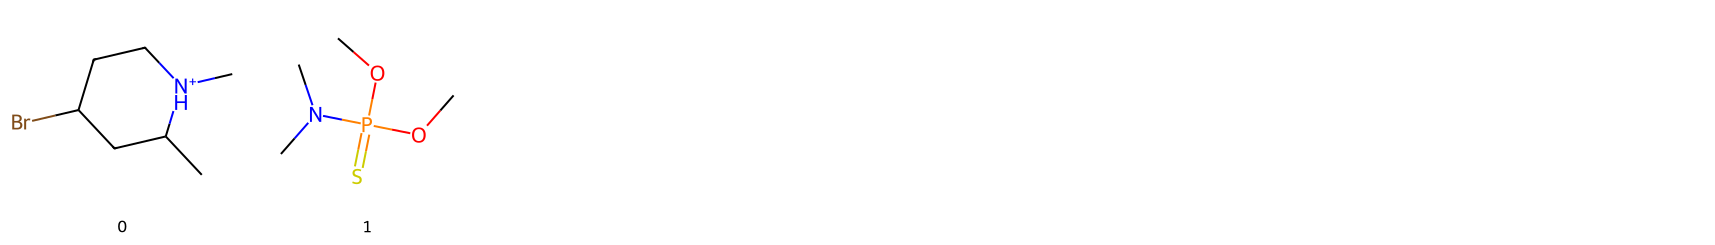

In [5]:
rng = np.random.default_rng(RANDOM_SEED)
seed_indices = rng.choice(len(graphs), size=N_SEEDS, replace=False)
seed_graphs = [graphs[int(idx)] for idx in seed_indices]
print('Selected seed indices:', seed_indices.tolist())
show_molecules(seed_graphs, n=N_SEEDS, title='Seed molecules for oracle study')


## Conditional Sampling Comparison

Compare the same seeded conditional sampling workflow with the oracle disabled and enabled.


Conditioning molecules


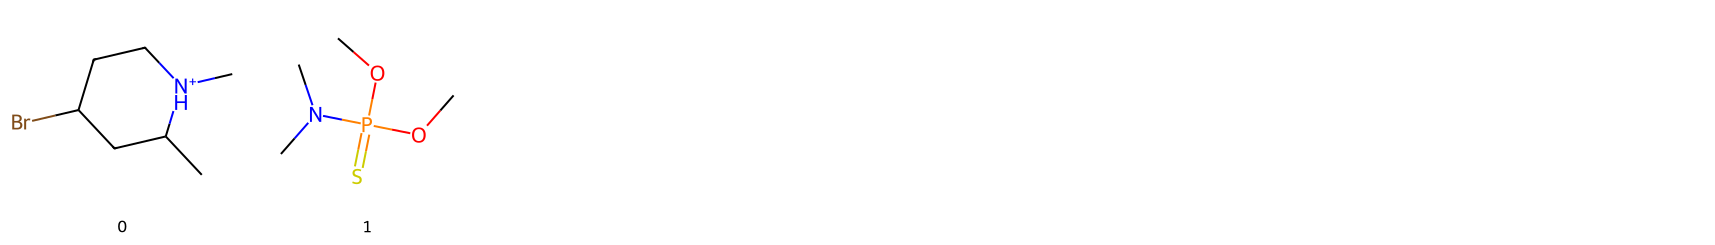

Node encoding 2 graphs
Class 'ConditionalNodeFieldGraphGenerator', Function 'node_encode' executed in 0.17 seconds (0.00 minutes, 0.00 hours).
Class 'ConditionalNodeFieldGraphGenerator', Function 'node_encode' executed in 0.17 seconds (0.00 minutes, 0.00 hours).
Encoding 2 graphs
Class 'ConditionalNodeFieldGraphGenerator', Function 'graph_encode' executed in 0.16 seconds (0.00 minutes, 0.00 hours).
Class 'ConditionalNodeFieldGraphGenerator', Function 'graph_encode' executed in 0.16 seconds (0.00 minutes, 0.00 hours).
Predicting node matrices for 128 graphs...
Generated graph 1/128: conditioning_nodes=9, conditioning_edges=9, predicted_nodes=12, mean_degree=2.17, max_degree=4, mean_edge_prob=0.291, max_edge_prob=0.902
  node_labels={'C': 5, 'Cl': 2, 'N': 2, 'O': 2, 'S': 1}
Generated graph 2/128: conditioning_nodes=9, conditioning_edges=9, predicted_nodes=12, mean_degree=2.17, max_degree=3, mean_edge_prob=0.287, max_edge_prob=0.831
  node_labels={'C': 6, 'Cl': 1, 'N': 3, 'O': 1, 'S': 1}


In [ ]:
oracle_sample_comparison = compare_oracle_samples(
    graph_generator,
    seed_graphs,
    n_samples=N_COMPARE_SAMPLES,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
    seed=RANDOM_SEED,
)


## Feasible-Rate Score Comparison

Keep the retry budget fixed and compare how often the full decode pipeline yields feasible candidates with and without the oracle.


In [ ]:
oracle_score_comparison = compare_oracle_score(
    graph_generator,
    n_samples=N_SCORE_SAMPLES,
    max_feasibility_attempts=MAX_FEASIBILITY_ATTEMPTS,
    feasibility_candidates_per_attempt=FEASIBILITY_CANDIDATES_PER_ATTEMPT,
    seed=RANDOM_SEED + 1,
)


## Interpolation Comparison

Inspect whether the oracle changes which intermediate molecules successfully decode along the same interpolation path.


In [ ]:
endpoint_a, endpoint_b = seed_graphs[0], seed_graphs[1]
oracle_interpolation_comparison = compare_oracle_interpolation(
    graph_generator,
    endpoint_a,
    endpoint_b,
    k=5,
    apply_feasibility_filtering=APPLY_FEASIBILITY_FILTERING,
)
